In [ ]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
!unzip /content/drive/MyDrive/GreenAI/Trashnet/dataset.zip -d /content/dataset

Archive:  /content/drive/MyDrive/GreenAI/Trashnet/dataset-resized2.zip
replace /content/dataset/dataset-resized/cardboard/cardboard1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
!ls /content/dataset

dataset-resized


In [ ]:
DATA_DIR = '/content/dataset/dataset-resized'

In [ ]:
MY_CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=MY_CLASSES, # This forces the model to only use these 5 folders
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=MY_CLASSES,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(6, activation='softmax') # Exactly 5 output units
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training on 5 classes...")
model.fit(train_ds, validation_data=val_ds, epochs=10)

Starting training on 5 classes...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.5262 - loss: 1.2086 - val_accuracy: 0.7327 - val_loss: 0.7557
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7413 - loss: 0.6919 - val_accuracy: 0.7762 - val_loss: 0.6359
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8002 - loss: 0.5530 - val_accuracy: 0.7822 - val_loss: 0.6080
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8299 - loss: 0.4918 - val_accuracy: 0.8059 - val_loss: 0.5487
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8294 - loss: 0.4567 - val_accuracy: 0.8198 - val_loss: 0.5247
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8620 - loss: 0.3987 - val_accuracy: 0.8218 - val_loss: 0.5173
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8709 - loss: 0.3655 - val_accuracy: 0.8158 - val_loss: 0.5083
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.8773 - loss: 0.

In [4]:
import tensorflow as tf

# Load your model (replace 'path_to_model' with your actual file path)
model = tf.keras.models.load_model('/content/drive/MyDrive/GreenAI/Trashnet/model.keras')

# Display the summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,358 (8.67 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

In [ ]:
# Evaluate on the validation dataset
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8337 - loss: 0.4826
Validation Accuracy: 83.37%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Get all images and true labels from the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print the report
# Ensure the target_names match the folders in your dataset
target_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Print the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

   cardboard       0.95      0.83      0.88        83
       glass       0.78      0.94      0.85       103
       metal       0.95      0.77      0.85        78
       paper       0.83      0.89      0.86       124
     plastic       0.81      0.72      0.76        88
       trash       0.63      0.76      0.69        29

    accuracy                           0.83 

/tmp/ipykernel_3276/4234694513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_names, y=f1_scores, palette='viridis')


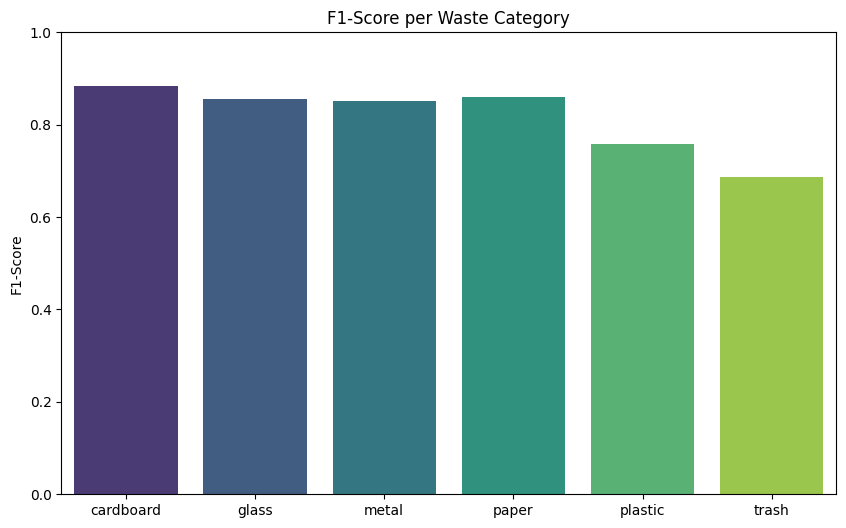

In [ ]:
from sklearn.metrics import f1_score

# Calculate F1 for each class
f1_scores = f1_score(y_true, y_pred, average=None)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_names, y=f1_scores, palette='viridis')
plt.title('F1-Score per Waste Category')
plt.ylabel('F1-Score')
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Assuming you save the fit result to a variable 'history'
# history = model.fit(train_ds, validation_data=val_ds, epochs=10)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

NameError: name 'history' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


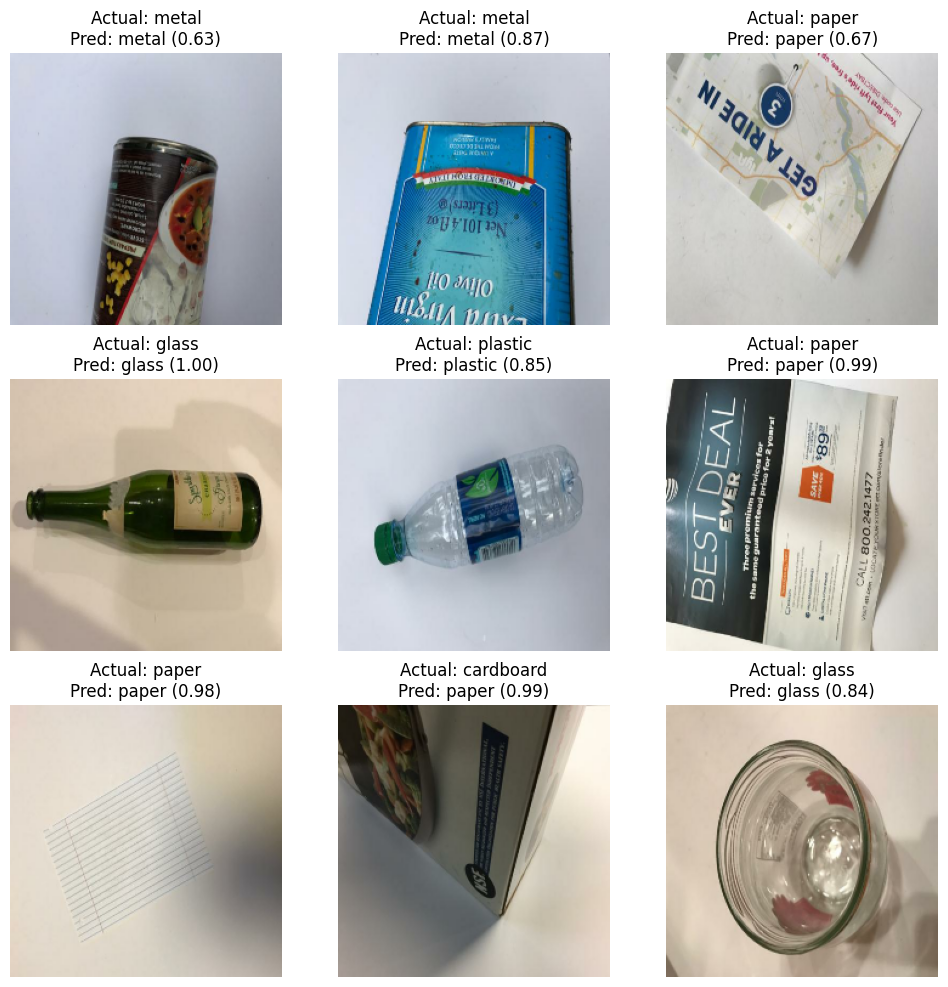

In [ ]:
import matplotlib.pyplot as plt

# Take one batch from validation set
images, labels = next(iter(val_ds))
predictions = model.predict(images)

plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    actual = target_names[np.argmax(labels[i])]
    predicted = target_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i])

    plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.2f})")
    plt.axis("off")

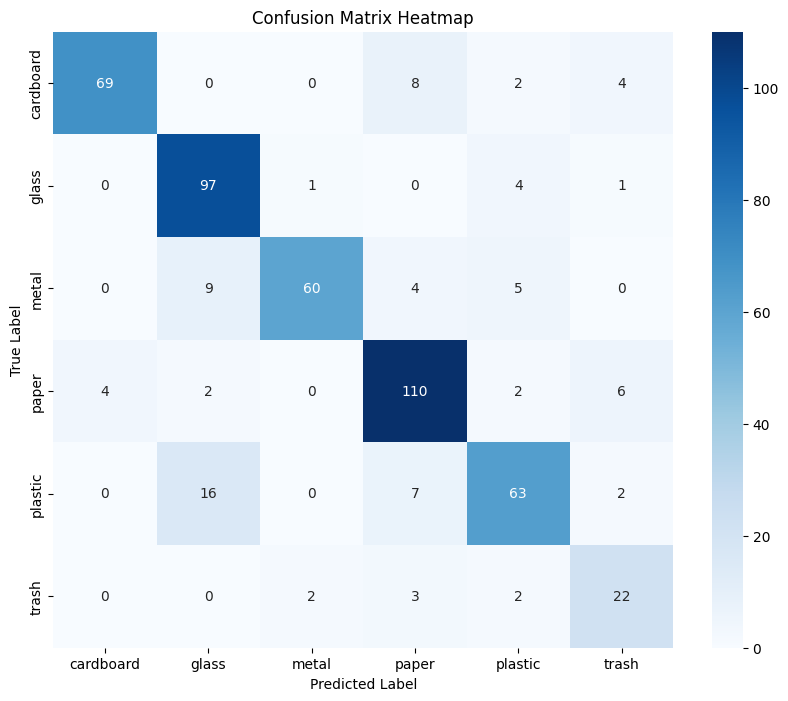

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix,
            annot=True,
            cmap="Blues",
            fmt='d',
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
def check_recyclable(label):
    recyclable_items = ["plastic", "paper", "metal", "glass", "cardboard"]

    if label.lower() in recyclable_items:
        return "Recyclable"
    else:
        return "Non-Recyclable"

In [ ]:
model.save("/content/drive/MyDrive/GreenAI/Trashnet/model.keras")

In [ ]:
import os
os.listdir()

In [ ]:
from google.colab import files
files.download("model.keras")